Credit Risk Analysis Pipeline

The purpose of this notebook is to learn and experiment with data science techniqes for credit risk analysis. A variety of techniques will be explored, including data preprocessing, feature engineering, model training, and evaluation before official implementation into my end-to-end, modular python package outside of this notebook.

## Setup
Import required libraries and configure display settings.

Reads the raw Excel data source directly and applies initial cleaning.

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Add project root to sys.path for module imports
# -----------------------------
root = "/Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation"
sys.path.append(root)

# -----------------------------
# Import external python modules
# -----------------------------
from pathlib import Path
from src.preprocessing import data_transformations
from src.preprocessing import data_cleaning
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve


# -----------------------------
# Display full dataframes
# -----------------------------
pd.set_option('display.max_rows', None) # reset_option to compact dataframe view
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

# -----------------------------
# Define path to raw Excel data source
# -----------------------------
excel_path = Path(
    '/Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation/src/data/raw/dataset_project_1.xlsx'
)

## Data Loading
Read raw Excel data and apply initial cleaning to standardize column names.

Continuously reads the output parquet file and prints changes to the DataFrame whenever new events are added.

In [2]:
# -----------------------------
# Read raw data from Excel source
# -----------------------------
raw_df = pd.read_excel(excel_path, skiprows=1)
print(f"Raw DataFrame shape: {raw_df.shape}")

# -----------------------------
# Apply initial data cleaning
# -----------------------------
sns.set_theme()
df = data_cleaning.clean_raw_data(raw_df)
print(f"Cleaned DataFrame shape: {df.shape}\n")
df.head()

Raw DataFrame shape: (45063, 8)
Cleaned DataFrame shape: (45063, 8)



,age,monthly_revenue,debt_ratio,rated_exposure,overdue_30_59_days,overdue_60_89_days,overdue_90_plus_days,serious_delinquencies_past_2_years
0,64,8158.000000,0.249908,0.000000,0,0,0,0
1,58,NaN,3870.000000,0.000000,0,0,0,0
2,41,6666.000000,0.456127,0.000000,0,0,0,0
3,43,10500.000000,0.000190,2.000000,0,0,0,0
4,49,400.000000,0.271820,0.000000,0,0,0,1


## Data Transformations
Backfill delinquency columns and create missing value indicator flags.

In [3]:
# Enforce monotonic severity for delinquencies
df_backfilled = data_transformations.backfill_overdues(df, col_1='overdue_30_59_days', col_2='overdue_60_89_days', col_3='overdue_90_plus_days')

# Track missing values in the original column
df_missing_val1 = data_transformations.is_missing_value(df_backfilled, col_orig='monthly_revenue', col_bool='revenue_missing')
df_missing_val2 = data_transformations.is_missing_value(df_missing_val1, col_orig='debt_ratio', col_bool='debt_ratio_missing')
df_missing_val3 = data_transformations.is_missing_value(df_missing_val2, col_orig='rated_exposure', col_bool='rated_exposure_missing')

df_transformed = df_missing_val3

df_transformed.head()

,age,monthly_revenue,debt_ratio,rated_exposure,overdue_30_59_days,overdue_60_89_days,overdue_90_plus_days,serious_delinquencies_past_2_years,revenue_missing,debt_ratio_missing,rated_exposure_missing
0,64,8158.000000,0.249908,0.000000,0,0,0,0,0,0,0
1,58,NaN,3870.000000,0.000000,0,0,0,0,1,0,0
2,41,6666.000000,0.456127,0.000000,0,0,0,0,0,0,0
3,43,10500.000000,0.000190,2.000000,0,0,0,0,0,0,0
4,49,400.000000,0.271820,0.000000,0,0,0,1,0,0,0


## Exploratory Data Analysis
Visualize distributions and apply log transformations to skewed variables.

<Axes: title={'center': 'Age (Binned)'}, xlabel='age_bin', ylabel='Count'>

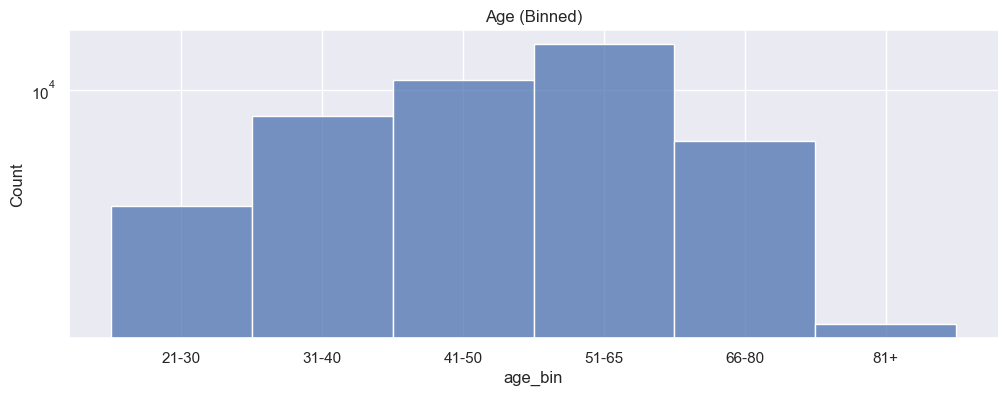

In [4]:
"""AGE"""

# Create the bins
age_raw = df_transformed[['age']].copy()

# Create age bins and labels
age_bins = [21, 30, 40, 50, 65, 80, 110]
age_labels = ['21-30','31-40','41-50','51-65','66-80','81+']

# Cut each row into its corresponding bin
age_raw['age_bin'] = pd.cut(age_raw['age'], 
                                            bins=age_bins, 
                                            labels=age_labels, 
                                            include_lowest=True)

# Add empty value category
age_raw['age_bin'] = (age_raw['age_bin'].cat.add_categories('NaN').fillna('NaN'))

# Display dataframe
age_raw.head()

"""Histogram Plot"""
x_var = 'age_bin'
plt.figure(figsize=(12,4))
plt.title("Age (Binned)")
sns.histplot(data=age_raw, x=x_var, log=True)

<Axes: title={'center': 'Monthly Revenue (Log-Transformed)'}, xlabel='monthly_revenue_log', ylabel='Count'>

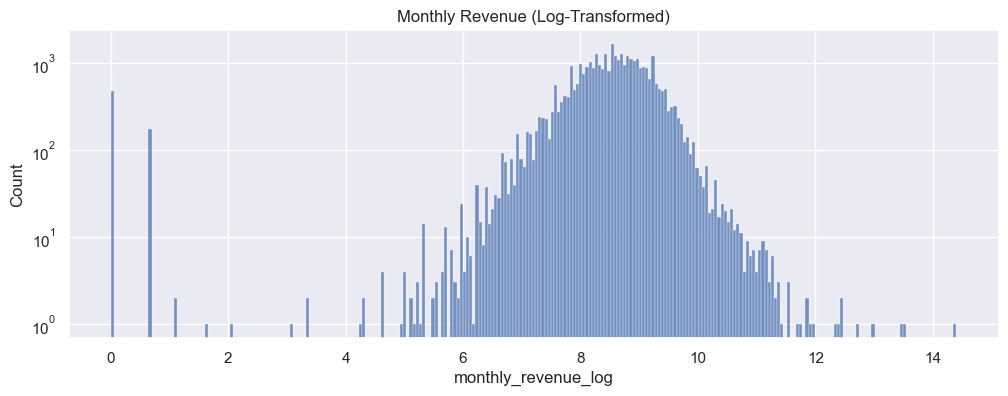

In [5]:
"""MONTHLY REVENUE"""

# Create the bins
monthly_revenue_raw = df_transformed[['monthly_revenue']].copy()

# Create revenue bins and labels
revenue_bins = [0, 5000, 10000, 15000, 20000, 25000, 50000, 100000, 999999999]
revenue_labels = ['0-5k', '5k-10k', '10k-15k', '15k-20k', '20k-25k', '25k-50k', '50k-100k', '100k+']

# Cut each row into its corresponding bin
monthly_revenue_raw['revenue_bin'] = pd.cut(monthly_revenue_raw['monthly_revenue'], 
                                            bins=revenue_bins, 
                                            labels=revenue_labels, 
                                            include_lowest=True)

# Add empty value category
monthly_revenue_raw['revenue_bin'] = (monthly_revenue_raw['revenue_bin'].cat.add_categories('NaN').fillna('NaN'))

# Display dataframe
monthly_revenue_raw.head()

"""Histogram Plot"""
x_var = 'revenue_bin'
plt.figure(figsize=(12,4))
plt.title("Monthly Revenue (Binned)")
# sns.histplot(data=monthly_revenue_raw, x=x_var, log=True)

"""Log Transform Distribution"""
df_transformed['monthly_revenue_log'] = np.log1p(df_transformed['monthly_revenue'])
plt.title("Monthly Revenue (Log-Transformed)")
plt.yscale('log')
sns.histplot(df_transformed['monthly_revenue_log'])

<Axes: title={'center': 'Debt Ratio (Log-Transformed)'}, xlabel='debt_ratio_log', ylabel='Count'>

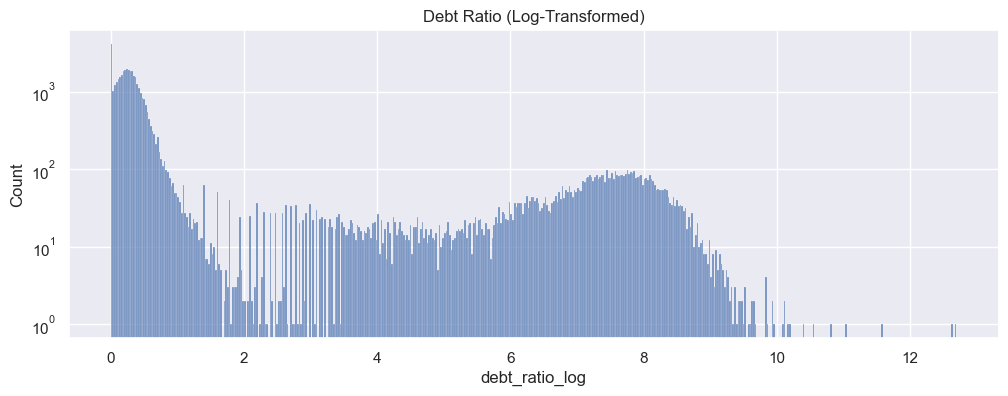

In [6]:
"""DEBT RATIO"""

# Create the bins
debt_ratio_raw = df_transformed[['debt_ratio']].copy()

# Create debt ratio bins and labels
debt_ratio_bins = [0, 1, 10, 50, 100, 500, 1000, 5000, 10000, 25000, 999999999]
debt_ratio_labels = ['0-1', '1-10', '10-50', '50-100', '100-500', '500-1000', '1000-5000', '5000-10000', '10000-25000', '25000+']

# Cut each row into its corresponding bin
debt_ratio_raw['debt_ratio_bin'] = pd.cut(debt_ratio_raw['debt_ratio'], 
                                            bins=debt_ratio_bins, 
                                            labels=debt_ratio_labels, 
                                            include_lowest=True)

# Add empty value category
debt_ratio_raw['debt_ratio_bin'] = (debt_ratio_raw['debt_ratio_bin'].cat.add_categories('NaN').fillna('NaN'))

# Display dataframe
debt_ratio_raw.head()

"""Histogram Plot"""
x_var = 'debt_ratio'
plt.figure(figsize=(12,4))
# plt.title("Debt Ratio (Binned)")
# sns.histplot(data=debt_ratio_raw, x=x_var, log=True)

"""Log Transform Distribution"""
df_transformed['debt_ratio_log'] = np.log1p(df_transformed['debt_ratio'])
plt.title("Debt Ratio (Log-Transformed)")
plt.yscale('log')
sns.histplot(df_transformed['debt_ratio_log'])

<Axes: title={'center': 'Rated Exposure (Log-Transformed)'}, xlabel='rated_exposure_log', ylabel='Count'>

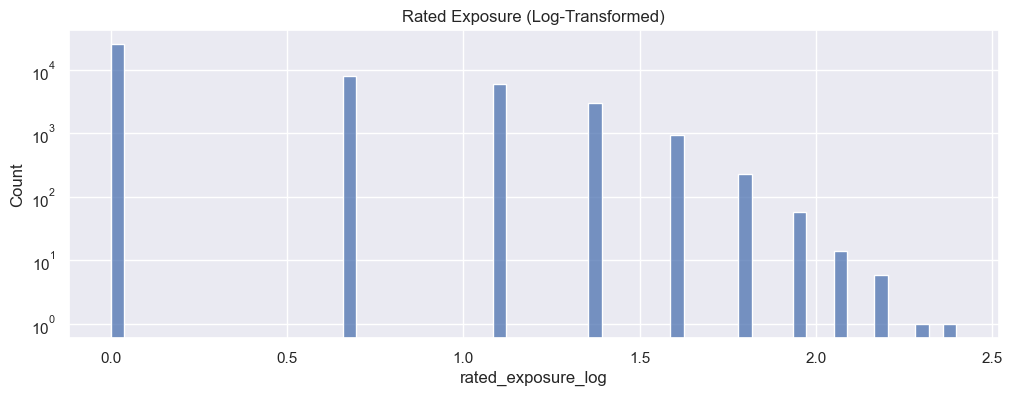

In [7]:
"""RATED EXPOSURE"""

# Create the bins
rated_exposure_raw = df_transformed[['rated_exposure']].copy()

# Create rated exposure bins and labels
rated_exposure_bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 100]
rated_exposure_labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8', '8-9', '9-10', '10-100']

# Cut each row into its corresponding bin
rated_exposure_raw['rated_exposure_bin'] = pd.cut(rated_exposure_raw['rated_exposure'], 
                                            bins=rated_exposure_bins, 
                                            labels=rated_exposure_labels, 
                                            include_lowest=True)

# Add empty value category
rated_exposure_raw['rated_exposure_bin'] = (rated_exposure_raw['rated_exposure_bin'].cat.add_categories('NaN').fillna('NaN'))

# Display dataframe
rated_exposure_raw.head()

"""Histogram Plot"""
x_var = 'rated_exposure'
plt.figure(figsize=(12,4))
# plt.title("Rated Exposure (Binned)")
# sns.histplot(data=rated_exposure_raw, x=x_var, log=True)

"""Log Transform Distribution"""
df_transformed['rated_exposure_log'] = np.log1p(df_transformed['rated_exposure'])
plt.title("Rated Exposure (Log-Transformed)")
plt.yscale('log')
sns.histplot(df_transformed['rated_exposure_log'])

<Axes: title={'center': 'Overdue Severity (Log-Transformed)'}, xlabel='overdue_severity_log', ylabel='Count'>

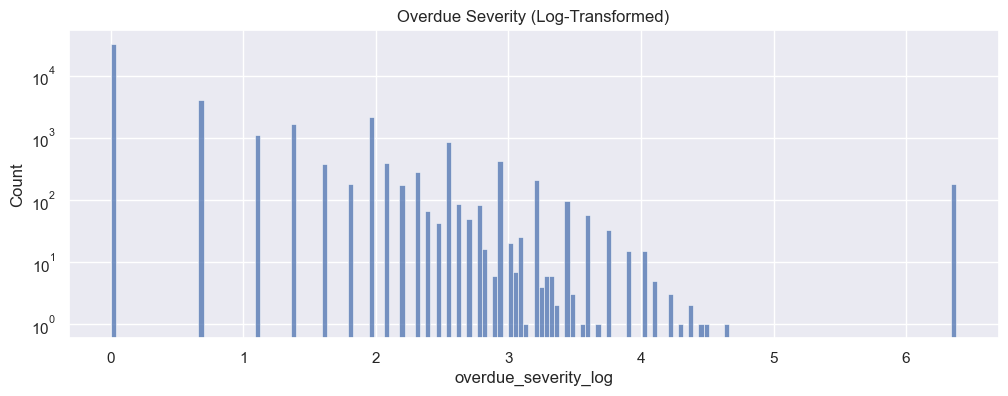

In [8]:
"""OVERDUE DAYS"""

low = 1
med = 2
high = 3

df_transformed['overdue_severity'] = (df_transformed['overdue_30_59_days'] * low) + (df_transformed['overdue_60_89_days'] * med) + (df_transformed['overdue_90_plus_days'] * high)

"""Log Transform Distribution"""
df_transformed['overdue_severity_log'] = np.log1p(df_transformed['overdue_severity'])
plt.figure(figsize=(12,4))
plt.title("Overdue Severity (Log-Transformed)")
plt.yscale('log')
sns.histplot(df_transformed['overdue_severity_log'])

## Missing Value Imputation
Normalize age and apply KNN imputation to fill missing values. Calculate composite business scale score.

In [9]:
# Normalize age column for 
df_transformed['age_normalized'] = (df_transformed['age'] - df_transformed['age'].min()) / (df_transformed['age'].max() - df_transformed['age'].min())

# KNN to impute missing values in variables used for segment-based scoring
impute_vars = ['monthly_revenue_log', 'rated_exposure_log', 'age_normalized']
imputer = KNNImputer(n_neighbors=5)
df_transformed[impute_vars] = imputer.fit_transform(df_transformed[impute_vars])

# Scale businesses based on revenue, rated exposure, and a normalized age
df_transformed['business_scale'] = (0.5 * df_transformed['monthly_revenue_log']) + (0.4 * df_transformed['rated_exposure_log']) + (0.1 * df_transformed['age_normalized'])

# Group businesses into tiers based on their scale (optional categorical feature for tree-based or linear models)
df_transformed['business_tier'] = pd.qcut(df_transformed['business_scale'], 4, labels=['small','medium','large','enterprise'])

df_transformed.head()

,age,monthly_revenue,debt_ratio,rated_exposure,overdue_30_59_days,overdue_60_89_days,overdue_90_plus_days,serious_delinquencies_past_2_years,revenue_missing,debt_ratio_missing,rated_exposure_missing,monthly_revenue_log,debt_ratio_log,rated_exposure_log,overdue_severity,overdue_severity_log,age_normalized,business_scale,business_tier
0,64,8158.000000,0.249908,0.000000,0,0,0,0,0,0,0,9.006877,0.223070,0.000000,0,0.000000,0.500000,4.553438,large
1,58,NaN,3870.000000,0.000000,0,0,0,0,1,0,0,8.985831,8.261268,0.000000,0,0.000000,0.430233,4.535939,large
2,41,6666.000000,0.456127,0.000000,0,0,0,0,0,0,0,8.804925,0.375780,0.000000,0,0.000000,0.232558,4.425718,large
3,43,10500.000000,0.000190,2.000000,0,0,0,0,0,0,0,9.259226,0.000190,1.098612,0,0.000000,0.255814,5.094639,enterprise
4,49,400.000000,0.271820,0.000000,0,0,0,1,0,0,0,5.993961,0.240449,0.000000,0,0.000000,0.325581,3.029539,small


## Outlier Detection
Flag outliers using interquartile range (IQR) analysis.

In [10]:
"""MONTHLY REVENUE OUTLIER"""
Q1 = df_transformed['monthly_revenue'].quantile(0.25) # low outlier
Q3 = df_transformed['monthly_revenue'].quantile(0.75) # high outlier
IQR = Q3 - Q1
df_transformed['revenue_outlier'] = ((df_transformed['monthly_revenue'] < Q1 - 1.5*IQR) | 
                         (df_transformed['monthly_revenue'] > Q3 + 1.5*IQR)).astype(int)

"""DEBT RATIO OUTLIER"""
Q1 = df_transformed['debt_ratio'].quantile(0.25)
Q3 = df_transformed['debt_ratio'].quantile(0.75)
IQR = Q3 - Q1
df_transformed['debt_ratio_outlier'] = ((df_transformed['debt_ratio'] < Q1 - 1.5*IQR) | 
                         (df_transformed['debt_ratio'] > Q3 + 1.5*IQR)).astype(int)

"""RATED EXPOSURE OUTLIER"""
Q1 = df_transformed['rated_exposure'].quantile(0.25)
Q3 = df_transformed['rated_exposure'].quantile(0.75)
IQR = Q3 - Q1
df_transformed['rated_exposure_outlier'] = ((df_transformed['rated_exposure'] < Q1 - 1.5*IQR) | 
                         (df_transformed['rated_exposure'] > Q3 + 1.5*IQR)).astype(int)

"""OVERDUE SEVERITY OUTLIER"""
Q1 = df_transformed['overdue_severity'].quantile(0.25)
Q3 = df_transformed['overdue_severity'].quantile(0.75)
IQR = Q3 - Q1
df_transformed['overdue_severity_outlier'] = ((df_transformed['overdue_severity'] < Q1 - 1.5*IQR) | 
                         (df_transformed['overdue_severity'] > Q3 + 1.5*IQR)).astype(int)

## Correlation Analysis
Generate correlation matrix heatmap for key variables.

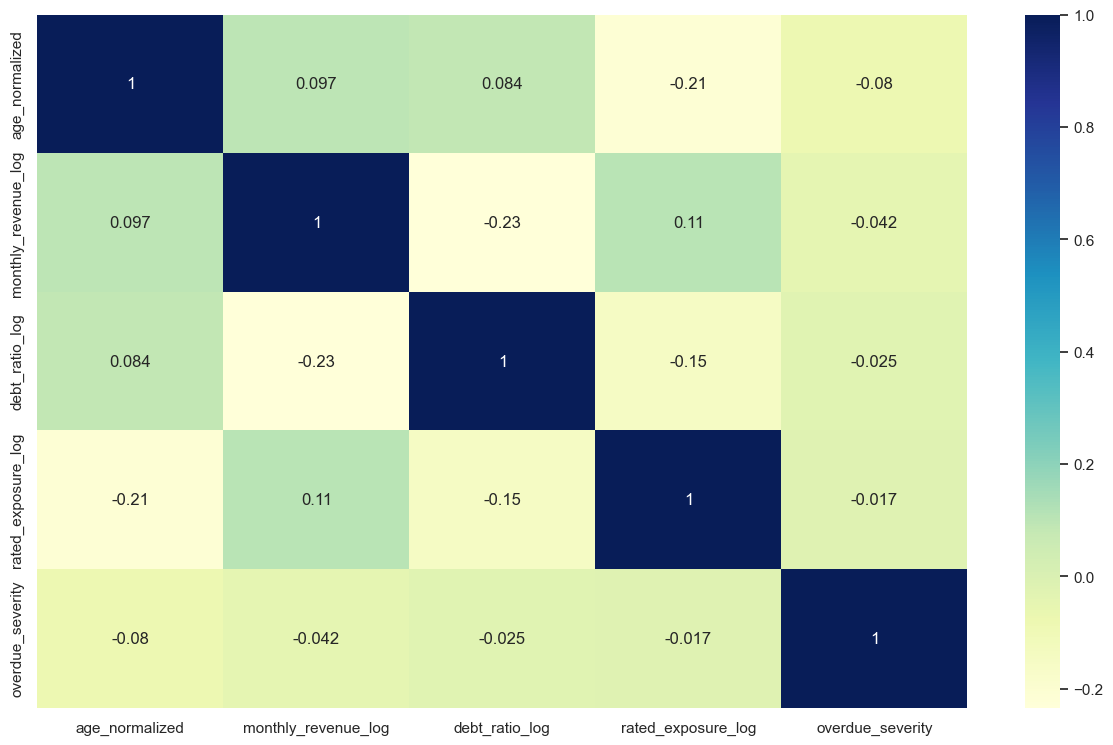

In [11]:
"""Seaborn and Line Plots"""
# plt.figure(figsize=(16,6))
# sns.lineplot(data=df['monthly_revenue']) # original

"""Line Plots"""
# plt.figure(figsize=(20,6))
# plt.title(current_var)
# sns.lineplot(data=df[current_var])

"""Bar Plots"""
# x_var = 'revenue_bin'
# y_var = 'rated_exposure'
# plt.figure(figsize=(25,8))
# plt.title(f'{x_var} vs. {y_var}')
# sns.barplot(x=monthly_revenue_raw[x_var], y=df_transformed[y_var])

"""Scatter Plots"""
# x_var = 'rated_exposure'
# y_var = 'age'
# plt.figure(figsize=(25,7))
# plt.title(f'{x_var} vs. {y_var}')
# sns.scatterplot(x=df[x_var], y=df[y_var])

"""Pie Graphs (Custom)"""
# plt.figure(figsize=(25,9))
# Plots.plot_age_ranges(df, 'age', title='% of Age Ranges')

"""Correlation Matrix"""
correlation_df = df_transformed[[
    'age_normalized', 
    'monthly_revenue_log', 
    'debt_ratio_log', 
    'rated_exposure_log', 
    'overdue_severity'
    ]].copy()

correlation_matrix = correlation_df.corr()
plt.figure(figsize=(15,9))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu')

plt.show()

## Modeling DataFrame
Select final features for model input and display summary statistics.

In [12]:
modeling_df = df_transformed[[
    'age_normalized',
    'monthly_revenue_log',
    'debt_ratio_log',
    'rated_exposure_log',
    'overdue_severity',
    'revenue_missing',
    'debt_ratio_missing',
    'rated_exposure_missing',
    'revenue_outlier',
    'debt_ratio_outlier',
    'rated_exposure_outlier',
    'overdue_severity_outlier',
    'business_scale',
    'serious_delinquencies_past_2_years',
]]

modeling_df.describe()

,age_normalized,monthly_revenue_log,debt_ratio_log,rated_exposure_log,overdue_severity,revenue_missing,debt_ratio_missing,rated_exposure_missing,revenue_outlier,debt_ratio_outlier,rated_exposure_outlier,overdue_severity_outlier,business_scale,serious_delinquencies_past_2_years
count,45063.000000,45063.000000,45063.000000,45063.000000,45063.000000,45063.000000,45063.000000,45063.000000,45063.000000,45063.000000,45063.000000,45063.000000,45063.000000,45063.000000
mean,0.351290,8.372753,1.495795,0.419649,3.892329,0.191798,0.000000,0.024788,0.032732,0.202872,0.094534,0.165945,4.389365,0.222489
std,0.170367,1.207468,2.597857,0.532698,37.033045,0.393720,0.000000,0.155479,0.177936,0.402142,0.292574,0.372036,0.662042,0.415922
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.220930,8.104401,0.162436,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.169243,0.000000
50%,0.348837,8.517393,0.317689,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.422884,0.000000
75%,0.476744,8.922792,0.618977,0.693147,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.731862,0.000000
max,1.000000,14.399992,12.696011,2.397895,588.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.254647,1.000000


## Validation
Verify the processed modeling parquet file.

In [13]:
file_path = '/Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation/src/data/processed/modeling_df.parquet'
processed_modeling_df = pd.read_parquet(file_path)

processed_modeling_df.head()

,age_normalized,monthly_revenue_log,debt_ratio_log,rated_exposure_log,overdue_severity,revenue_missing,debt_ratio_missing,rated_exposure_missing,revenue_outlier,debt_ratio_outlier,rated_exposure_outlier,overdue_severity_outlier,business_scale,serious_delinquencies_past_2_years
0,0.500000,9.006877,0.223070,0.000000,0.000000,0,0,0,0,0,0,0,4.553438,0.000000
1,0.430233,8.985831,8.261268,0.000000,0.000000,1,0,0,0,1,0,0,4.535939,0.000000
2,0.232558,8.804925,0.375780,0.000000,0.000000,0,0,0,0,0,0,0,4.425718,0.000000
3,0.255814,9.259226,0.000190,1.098612,0.000000,0,0,0,0,0,0,0,5.094639,0.000000
4,0.325581,5.993961,0.240449,0.000000,5.000000,0,0,0,0,0,0,0,3.029539,1.000000


## Linear Regression

Building, training, & testing a logistic regression model to predict the target variable based on the processed features.

In [14]:
"""Initialize Variables"""
modeling_df = modeling_df.copy()

feature_cols = [
    'age_normalized',
    'monthly_revenue_log',
    'debt_ratio_log',
    'rated_exposure_log',
    'revenue_missing',
    'debt_ratio_missing',
    'rated_exposure_missing',
    'revenue_outlier',
    'debt_ratio_outlier',
    'rated_exposure_outlier'
]

# Add default flag column and set target variable
modeling_df['default_flag'] = (modeling_df['serious_delinquencies_past_2_years'] > 0).astype(int)

# Initialize logistic regression variables
X = modeling_df[feature_cols]
Y = modeling_df.default_flag

"""Split Data"""
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=.5, random_state=24)

"""Model Training and Creating Predictions"""
# Using class_weight='balanced' to handle class imbalance
log_reg = LogisticRegression(random_state=24, class_weight='balanced', max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

"""Evaluating the Trained Model's Performance"""
# Confusion Matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
cnf_matrix


array([[9930, 7586],
       [1917, 3099]])

Text(0.5, 427.9555555555555, 'Predicted label')

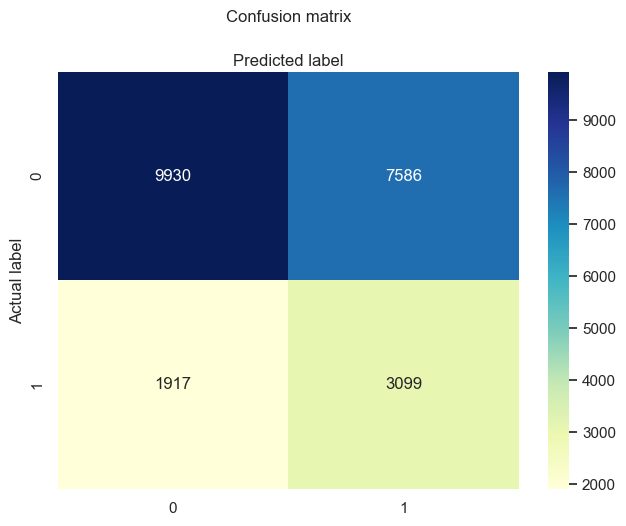

In [15]:
# Heatmap
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [16]:
# Evaluation Metrics
target_names = ['no default', 'default']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

  no default       0.84      0.57      0.68     17516
     default       0.29      0.62      0.39      5016

    accuracy                           0.58     22532
   macro avg       0.56      0.59      0.54     22532
weighted avg       0.72      0.58      0.61     22532



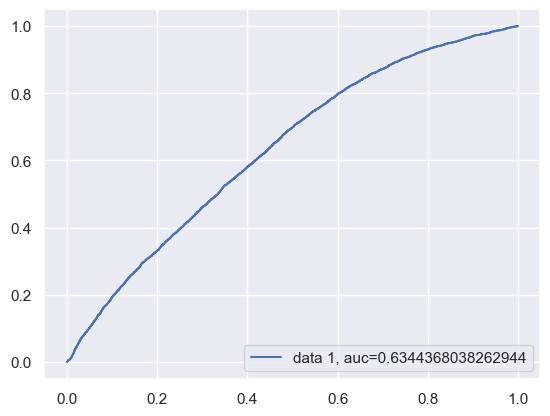

In [17]:
"""Receiving Operating Curve (ROC)"""
y_pred_proba = log_reg.predict_proba(X_test)[::,1]
fpr, tpr, _ = roc_curve(y_test,  y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()